## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np



##  Set Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Load CIFAR-10 Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

# Example shape
example_data, _ = next(iter(train_loader))
print("Image shape:", example_data[0].shape)  # (3, 32, 32)

100%|██████████| 170M/170M [00:03<00:00, 44.0MB/s]


Image shape: torch.Size([3, 32, 32])


## Define VAE

In [4]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(ConvVAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # -> 32x16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # -> 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # -> 128x4x4
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(128*4*4, latent_dim)
        self.fc_logvar = nn.Linear(128*4*4, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 128*4*4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # -> 64x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # -> 32x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),  # -> 3x32x32
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = self.flatten(h)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


## Define VAE Loss Function

In [5]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_loss


## Train the VAE

In [6]:
conv_vae = ConvVAE().to(device)

def train_vae(model, loader, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        print(f"Epoch [{epoch+1}/{epochs}]")

        for imgs, _ in loader:
            imgs = imgs.to(device)
            recon, mu, logvar = model(imgs)
            loss = vae_loss(recon, imgs, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Avg Loss: {total_loss / len(loader.dataset):.4f}")

train_vae(conv_vae, train_loader, epochs=20)



Epoch [1/20]
Avg Loss: 116.5104
Epoch [2/20]
Avg Loss: 85.2443
Epoch [3/20]
Avg Loss: 80.7652
Epoch [4/20]
Avg Loss: 78.9676
Epoch [5/20]
Avg Loss: 77.9410
Epoch [6/20]
Avg Loss: 77.2905
Epoch [7/20]
Avg Loss: 76.7226
Epoch [8/20]
Avg Loss: 76.1976
Epoch [9/20]
Avg Loss: 75.9125
Epoch [10/20]
Avg Loss: 75.7214
Epoch [11/20]
Avg Loss: 75.4488
Epoch [12/20]
Avg Loss: 75.2617
Epoch [13/20]
Avg Loss: 75.1656
Epoch [14/20]
Avg Loss: 75.0034
Epoch [15/20]
Avg Loss: 74.8965
Epoch [16/20]
Avg Loss: 74.8335
Epoch [17/20]
Avg Loss: 74.7367
Epoch [18/20]
Avg Loss: 74.5994
Epoch [19/20]
Avg Loss: 74.6408
Epoch [20/20]
Avg Loss: 74.4981


## Reconstruct Some CIFAR-10 Images

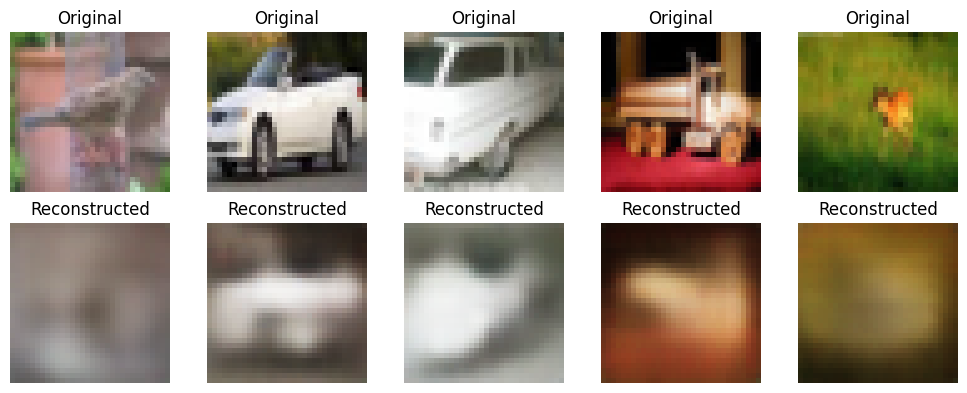

In [7]:
conv_vae.eval()
with torch.no_grad():
    imgs, _ = next(iter(train_loader))
    imgs = imgs[:5].to(device)
    recon_imgs, _, _ = conv_vae(imgs)
    recon_imgs = recon_imgs.cpu()

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(np.transpose(imgs[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(np.transpose(recon_imgs[i].numpy(), (1, 2, 0)))
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()


##  Generate 5 Images from N(μ=5, σ²=1)

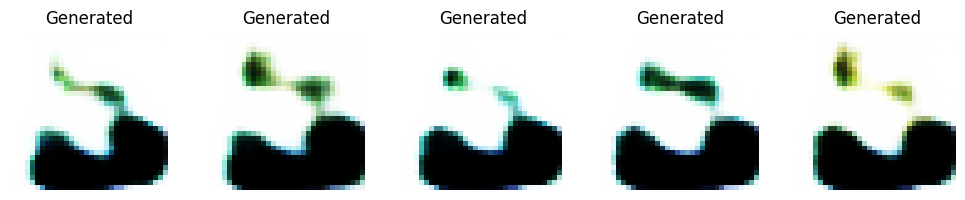

In [8]:
latent_dim = conv_vae.latent_dim
noise = torch.randn((5, latent_dim)) * 1 + 5  # N(5,1)
noise = noise.to(device)

with torch.no_grad():
    gen_imgs = conv_vae.decode(noise)

gen_imgs = gen_imgs.cpu()

plt.figure(figsize=(10, 2))
for i, img in enumerate(gen_imgs):
    plt.subplot(1, 5, i+1)
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title("Generated")
    plt.axis('off')
plt.tight_layout()
plt.show()
